# Intro

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%cd /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/

/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis


In [2]:
TEST_RESULTS_PATH = 'thesis-figures/extended_cbm/results/2_test_metrics_aab_con.parquet'
VAL_RESULTS_PATH_RAW = 'thesis-figures/extended_cbm/results/1_extended_cbm_results.parquet'

In [3]:
def create_summary_table(df: pd.DataFrame, filter_tag:list[str], reference_measure:str):
    """Erstellt eine Tabelle mit den Bestwerten pro Run."""
    print("\nErstelle Summary Tabelle (Max-Werte)...")

    # filter df for each column where df[column] is true
    for tag in filter_tag:
        col = f"tag_{tag}"
        if col not in df.columns:
            raise ValueError(f"Tag-Spalte {col} existiert nicht im DataFrame.")
        df = df[df[col] == True]

    if df.empty:
        print("DataFrame nach Tag-Filter leer.")
        return df

    # Sicherstellen, dass innerhalb jedes Runs nach step sortiert ist
    df = df.sort_values(["run_id", "_step"]).copy()

    # Epoch als laufende Evaluation pro run_id (startet bei 0)
    df["epoch"] = df.groupby("run_id").cumcount()

    # Bestes F1-Concept pro Run auswählen
    best_per_run = (
        df.loc[df.groupby("run_id")[reference_measure].idxmax()]
        .reset_index(drop=True)
    )
    
    # Speichern
    best_per_run.to_parquet("thesis-figures/extended_cbm/results/2_extended_cbm_results_best.parquet")
    print("Tabelle gespeichert unter: 2_extended_cbm_results_best.parquet")
    return best_per_run

In [4]:
test_results = pd.read_parquet(TEST_RESULTS_PATH)
val_results_raw = pd.read_parquet(VAL_RESULTS_PATH_RAW)

val_results = create_summary_table(val_results_raw, filter_tag=["aab-con"], reference_measure=r'$F_1$-Score Concepts')


Erstelle Summary Tabelle (Max-Werte)...
Tabelle gespeichert unter: 2_extended_cbm_results_best.parquet


In [5]:
val_results['run_id'].nunique()

29

In [6]:
val_results.head()

,_step,Recall Concepts,Precision Concepts,Total Loss,Mean IoU,Foreground Dice,$F_1$-Score Concepts,Mean Dice,Concept Accuracy,Runtime,...,Segmentation Module,Concept Criterion,Use Soft Labels,unified_model,Dataset,Concept Loss,tag_aab-con,tag_aab-con-maskreg-intro,tag_aab-soft-bce,tag_aab-aff
0,13281,0.952128,0.978961,0.024638,0.835294,0.210124,0.963265,0.849626,0.991282,15008.149322,...,SETR-PUP,BCEWithLogitsLoss,no,None,FunnyBirds,0.024638,True,None,None,None
1,10156,0.985865,0.992989,0.017692,0.813633,0.003964,0.989225,0.813998,0.996667,12832.556127,...,SegDINO,BCEWithLogitsLoss,no,segdino_b,FunnyBirds,0.017692,True,None,None,None
2,19531,0.987591,0.993029,0.020113,0.814214,0.023301,0.990119,0.816216,0.996154,25389.943338,...,SegDINO,BCEWithLogitsLoss,no,segdino_b,FunnyBirds,0.020113,True,None,None,None
3,1798,0.452661,0.450022,0.757549,0.668160,0.043310,0.448697,0.671453,0.769117,10867.147639,...,Upscaled SingleLayer,BCEWithLogitsLoss,no,None,CUB_112,0.757549,True,None,None,None
4,14843,0.973212,0.974512,0.026885,0.827219,0.200428,0.972965,0.841928,0.990513,16201.438018,...,SETR-PUP,BCEWithLogitsLoss,no,None,FunnyBirds,0.026885,True,None,None,None


In [7]:
import textwrap


def wrap_labels(series, width=12):
    return series.apply(lambda x: "\n".join(textwrap.wrap(str(x), width)))



def plot_ablation_heatmaps_paper(
    df: pd.DataFrame,
    metric_l: str = "Foreground Dice",
    metric_r: str = "Mean Dice",
):
    """
    Creates publication-quality heatmaps for ablation studies.

    - Respects internal categorical ordering (if present).
    - Uses consistent color normalization across both heatmaps.
    - Ensures stable ordering and reproducible aggregation.
    """

    # -------------------------
    # 1) Respect internal categorical ordering
    # -------------------------
    concept_order = (
        df["Concept Module"].cat.categories
        if isinstance(df["Concept Module"].dtype, pd.CategoricalDtype)
        else df["Concept Module"].unique()
    )

    seg_order = (
        df["Segmentation Module"].cat.categories
        if isinstance(df["Segmentation Module"].dtype, pd.CategoricalDtype)
        else df["Segmentation Module"].unique()
    )

    # -------------------------
    # 2) Aggregate (mean over runs)
    # -------------------------
    agg_df = (
        df.groupby(
            ["Concept Module", "Segmentation Module"],
            observed=True,
            sort=False
        )[[metric_l, metric_r]]
        .mean()
        .reset_index()
    )

    # Preserve categorical ordering explicitly
    agg_df["Concept Module"] = pd.Categorical(
        agg_df["Concept Module"], categories=concept_order, ordered=True
    )
    agg_df["Segmentation Module"] = pd.Categorical(
        agg_df["Segmentation Module"], categories=seg_order, ordered=True
    )

    # -------------------------
    # 3) Pivot tables
    # -------------------------
    hm_l = (
        agg_df.pivot(
            index="Concept Module",
            columns="Segmentation Module",
            values=metric_l,
        )
        .reindex(index=concept_order, columns=seg_order)
    )

    hm_r = (
        agg_df.pivot(
            index="Concept Module",
            columns="Segmentation Module",
            values=metric_r,
        )
        .reindex(index=concept_order, columns=seg_order)
    )

    # -------------------------
    # 4) Shared color normalization
    # -------------------------
    vmin = np.nanmin([hm_l.values.min(), hm_r.values.min()])
    vmax = np.nanmax([hm_l.values.max(), hm_r.values.max()])

    # -------------------------
    # 5) Plot styling (paper-like)
    # -------------------------
    sns.set_theme(style="white")
    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(10, 5),
        sharey=True,
        constrained_layout=True
    )

    heatmap_kwargs = dict(
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        vmin=vmin,
        vmax=vmax,
        linewidths=0.8,
        linecolor="white",
        square=True,
        annot_kws={"size": 8}
    )

    # Left heatmap (no colorbar)
    sns.heatmap(hm_l, ax=ax1, cbar=False, **heatmap_kwargs)

    # Right heatmap (with shared colorbar)
    sns.heatmap(
        hm_r,
        ax=ax2,
        cbar=True,
        cbar_kws={"shrink": 0.8, "label": "Score"},
        **heatmap_kwargs
    )

    # -------------------------
    # 6) Axis formatting
    # -------------------------
    ax1.set_title(f"Localization\n({metric_l})", pad=10)
    ax2.set_title(f"Overall Performance\n({metric_r})", pad=10)

    ax1.set_xlabel("Segmentation Module")
    ax2.set_xlabel("Segmentation Module")
    ax1.set_ylabel("Concept Module")

    # ---- X-Ticks für beide ----
    for ax in (ax1, ax2):
        ax.tick_params(axis="x", length=0)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    # ---- Y-Ticks NUR links setzen ----
    ax1.tick_params(axis="y", length=0)
    ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

    # Rechts explizit ausschalten (sauberer bei shared axes)
    ax2.tick_params(axis="y", left=False, labelleft=False)
    
    return fig

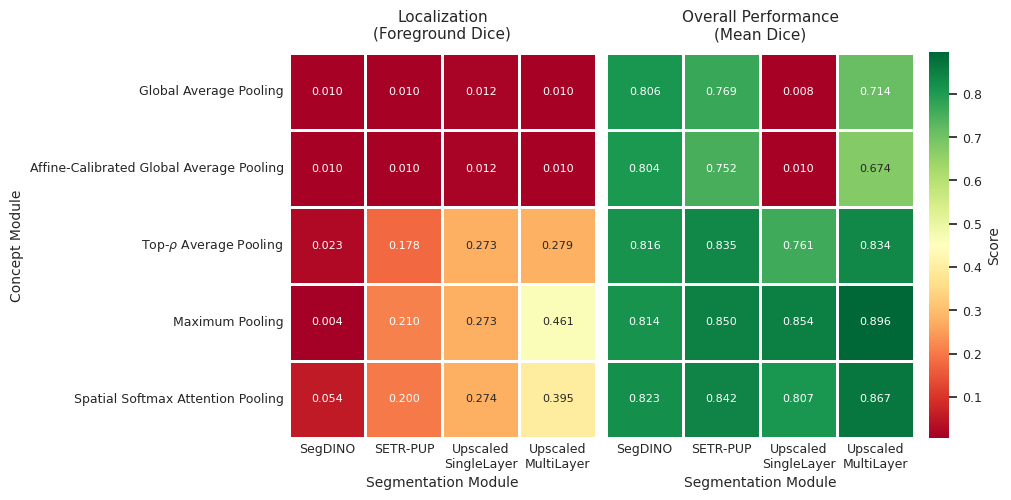

In [8]:
val_results["Segmentation Module"] = wrap_labels(val_results["Segmentation Module"])
fig = plot_ablation_heatmaps_paper(val_results[val_results['Dataset']=='FunnyBirds'])

fig.savefig(
    "thesis-figures/extended_cbm/outputs/heatmap_concept.pdf",
    bbox_inches="tight"
)

# Tables

## FunnyBirds

In [9]:
val_results_fb = val_results[val_results['Dataset'] == 'FunnyBirds']
len(val_results_fb)

20

In [10]:
val_table_fb = val_results_fb[['Segmentation Module', 'Concept Module', 
            '$F_1$-Score Concepts', 'Precision Concepts', 
            'Recall Concepts', 'Concept Accuracy', 
            'Mean Dice', 'Foreground Dice', 
            'Mean IoU', 
       ]].copy().sort_values(['Segmentation Module', 'Concept Module'])

In [11]:
l = val_table_fb.to_latex()

print(l)

\begin{tabular}{lllrrrrrrr}
\toprule
 & Segmentation Module & Concept Module & $F_1$-Score Concepts & Precision Concepts & Recall Concepts & Concept Accuracy & Mean Dice & Foreground Dice & Mean IoU \\
\midrule
13 & SegDINO & Global Average Pooling & 0.990256 & 0.994757 & 0.986303 & 0.996667 & 0.806201 & 0.009922 & 0.805313 \\
23 & SegDINO & Affine-Calibrated Global Average Pooling & 0.992600 & 0.992819 & 0.992620 & 0.996923 & 0.803673 & 0.009935 & 0.802784 \\
2 & SegDINO & Top-$\rho$ Average Pooling & 0.990119 & 0.993029 & 0.987591 & 0.996154 & 0.816216 & 0.023301 & 0.814214 \\
1 & SegDINO & Maximum Pooling & 0.989225 & 0.992989 & 0.985865 & 0.996667 & 0.813998 & 0.003964 & 0.813633 \\
6 & SegDINO & Spatial Softmax Attention Pooling & 0.993953 & 0.998700 & 0.989508 & 0.997179 & 0.822566 & 0.053568 & 0.817913 \\
12 & SETR-PUP & Global Average Pooling & 0.957908 & 0.965275 & 0.954491 & 0.988462 & 0.768807 & 0.010210 & 0.767895 \\
15 & SETR-PUP & Affine-Calibrated Global Average Pooling 

## CUB112

In [12]:
val_results_cub = val_results[val_results['Dataset'] == 'CUB_112']

In [13]:
val_table_cub = val_results_cub[['Segmentation Module', 'Concept Module', 
            '$F_1$-Score Concepts', 'Precision Concepts', 
            'Recall Concepts', 'Concept Accuracy', 
            'Mean Dice', 'Foreground Dice', 
            'Mean IoU', 
       ]].copy().sort_values(['Segmentation Module', 'Concept Module'])
len(val_table_cub)

9

In [14]:
l = val_table_cub.to_latex()

print(l)

\begin{tabular}{lllrrrrrrr}
\toprule
 & Segmentation Module & Concept Module & $F_1$-Score Concepts & Precision Concepts & Recall Concepts & Concept Accuracy & Mean Dice & Foreground Dice & Mean IoU \\
\midrule
27 & SETR-PUP & Top-$\rho$ Average Pooling & 0.502740 & 0.571583 & 0.461109 & 0.816890 & 0.701209 & 0.110572 & 0.692833 \\
19 & SETR-PUP & Maximum Pooling & 0.509374 & 0.557307 & 0.483711 & 0.810756 & 0.715872 & 0.095854 & 0.708749 \\
9 & SETR-PUP & Spatial Softmax Attention Pooling & 0.494572 & 0.557771 & 0.468217 & 0.810585 & 0.569160 & 0.091768 & 0.561415 \\
14 & Upscaled
SingleLayer & Top-$\rho$ Average Pooling & 0.454782 & 0.456907 & 0.458751 & 0.772784 & 0.539990 & 0.078491 & 0.533916 \\
3 & Upscaled
SingleLayer & Maximum Pooling & 0.448697 & 0.450022 & 0.452661 & 0.769117 & 0.671453 & 0.043310 & 0.668160 \\
24 & Upscaled
SingleLayer & Spatial Softmax Attention Pooling & 0.446485 & 0.445573 & 0.452104 & 0.767052 & 0.568297 & 0.069470 & 0.562951 \\
11 & Upscaled
MultiLayer 